In [38]:
# 9.2 에임스 주택 데이터셋 탐색

In [39]:
import pandas as pd


columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
           'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt',
                 sep='\t',
                 usecols=columns)

df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [40]:
print(df.shape)

(2930, 6)


In [41]:
df.isnull().sum()

,0
Overall Qual,0
Overall Cond,0
Total Bsmt SF,1
Central Air,0
Gr Liv Area,0
SalePrice,0


In [42]:
df = df.dropna(axis=0)
print(df.isnull().sum())
print(df.shape)

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64
(2929, 6)


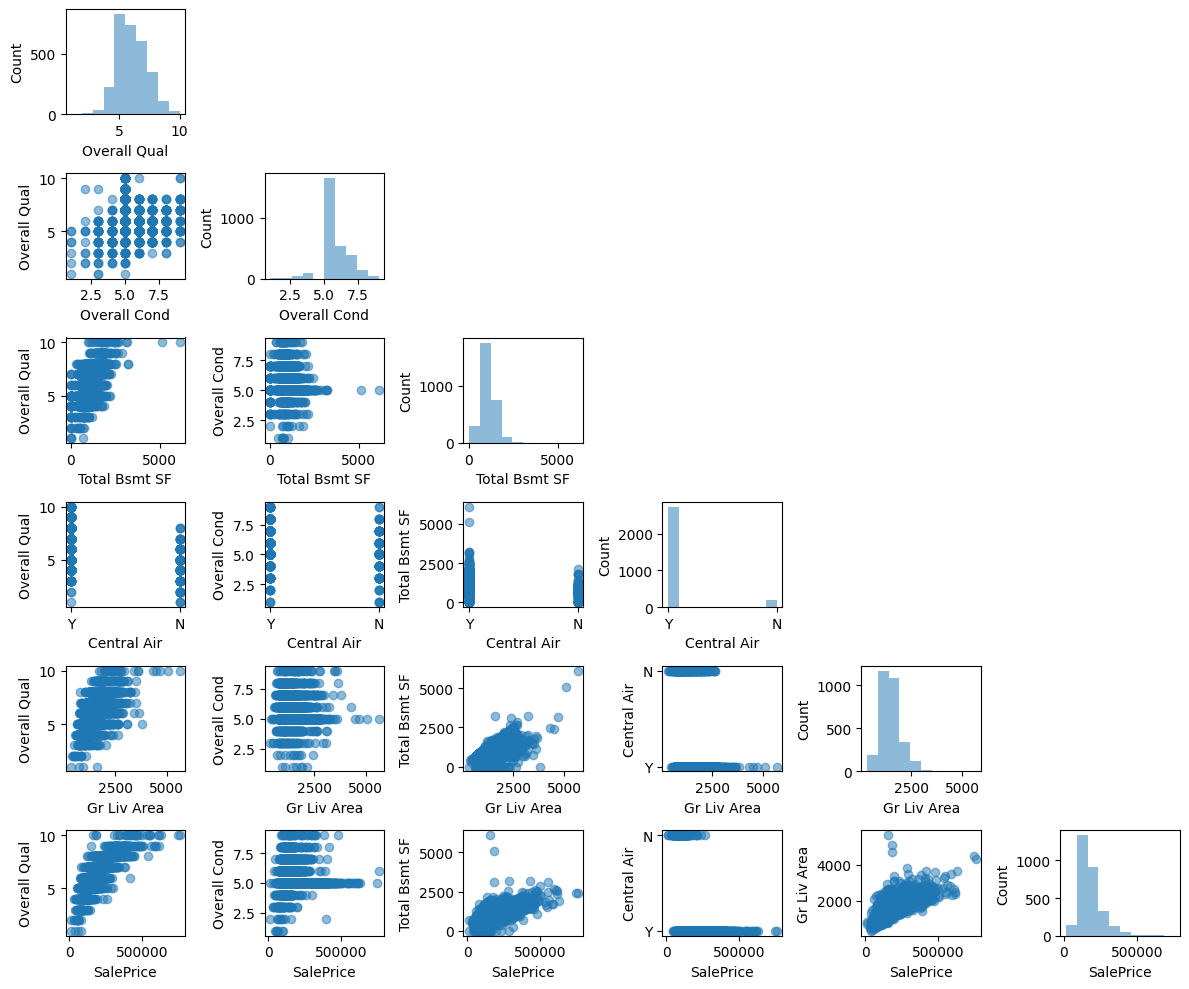

In [43]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df.values, figsize=(12, 10),
                  names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

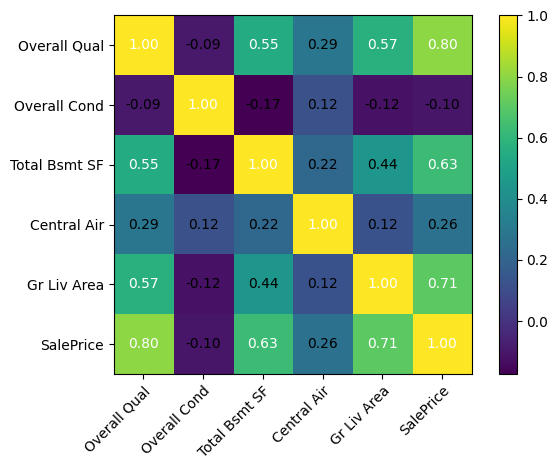

In [44]:
import numpy as np
from mlxtend.plotting import heatmap
import matplotlib.pyplot as plt
# Convert 'Central Air' column to numerical (Y=1, N=0)
df['Central Air'] = df['Central Air'].map({'Y': 1, 'N': 0})

cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)

plt.tight_layout()
plt.show()

In [60]:
# 9.3.2
from sklearn.linear_model import LinearRegression

X = df[['Gr Liv Area']].values
y = df['SalePrice'].values

slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f'기울기: {slr.coef_[0]:.3f}')
print(f'절편: {slr.intercept_:.3f}')

기울기: 111.666
절편: 13342.979


In [61]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='black', lw=2)
    return

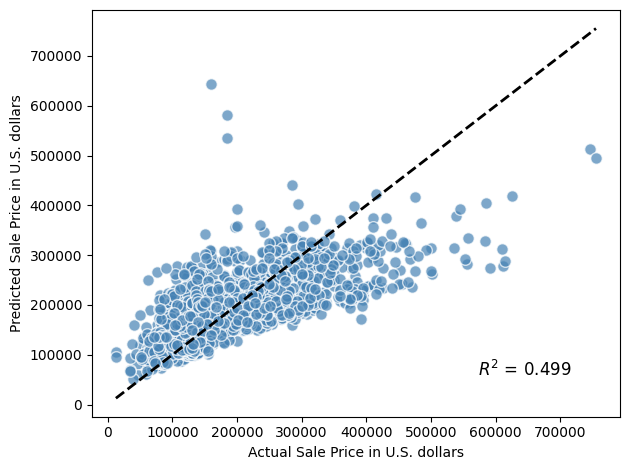

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.scatter(y, y_pred, c='steelblue', edgecolor='white', s=70, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Sale Price in U.S. dollars')
plt.ylabel('Predicted Sale Price in U.S. dollars')

# Calculate R-squared
r2_multi = r2_score(y, y_pred)

# Add R-squared text to the plot, repositioned to bottom-right
plt.text(y.max() - (y.max() - y.min()) * 0.05, y.min() + (y.max() - y.min()) * 0.05,
         f'$R^2$ = {r2_multi:.3f}',
         fontsize=12, ha='right', va='bottom')

plt.tight_layout()
plt.show()

In [63]:
# 9.3.2
from sklearn.linear_model import LinearRegression

X = df[['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF']].values
y = df['SalePrice'].values

slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f'기울기: {slr.coef_[0]:.3f}')
print(f'절편: {slr.intercept_:.3f}')



기울기: 27330.677
절편: -122656.819


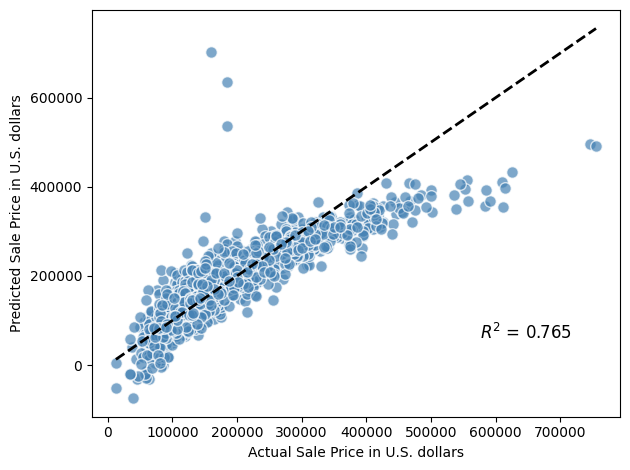

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.scatter(y, y_pred, c='steelblue', edgecolor='white', s=70, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Sale Price in U.S. dollars')
plt.ylabel('Predicted Sale Price in U.S. dollars')

# Calculate R-squared
r2_multi = r2_score(y, y_pred)

# Add R-squared text to the plot, repositioned to bottom-right
plt.text(y.max() - (y.max() - y.min()) * 0.05, y.min() + (y.max() - y.min()) * 0.05,
         f'$R^2$ = {r2_multi:.3f}',
         fontsize=12, ha='right', va='bottom')

plt.tight_layout()
plt.show()